# Husky vs. Wolf — Minimal Notebook

**What you'll do:**
1. Load the model (or train once if weights are missing).
2. Predict on an image.
3. Generate a Grad‑CAM heatmap.

## 1) Setup (imports + paths)
If you're running this on a fresh environment, you may need to install dependencies first (uncomment the next cell).

In [1]:
# Optional: install if needed
# !pip install torch torchvision grad-cam imageio

In [2]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
import random

FILE_DIR = Path.cwd()
PROJECT_DIR = FILE_DIR.parent.parent
print(PROJECT_DIR)
WEIGHTS = PROJECT_DIR / "models" / "huskywolf" / "binary_classifier.pth"

from src import get_model, predict_image, grad_cam_explain
# load if weights exist, otherwise train on your dataset and save weights
model = get_model(
    weights_path=WEIGHTS,
    data_root=PROJECT_DIR,      # used only if training is needed
    train_if_missing=True,
    epochs=20, lr=0.01
)
print("Model is ready:", type(model).__name__)


/Users/juliawenkmann/Documents/CodingProjects/damien/xai-reproductions
Model is ready: BinaryClassifier


## 2) Predict on an image
Set `IMG` to any test image. If you keep the original project layout (`dataset/test/...`), the next cell will try to **auto-pick** one for you.

Picked image: /Users/juliawenkmann/Documents/CodingProjects/damien/xai-reproductions/datasets/huskywolf/test/greywolf_0.jpg


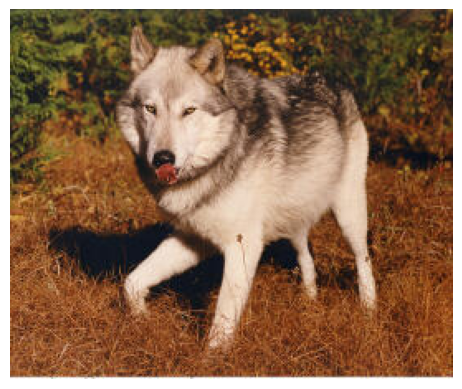

Predicted probabilities: {'prob_class1_wolf': 0.9999673366546631, 'prob_class0_husky': 3.266334533691406e-05}


In [3]:
# Try to auto-pick a test image; otherwise set IMG manually.
def pick_any_image(project_dir: Path) -> Path | None:
    exts = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG")
    all_image_files = []
    for ext in exts:
        all_image_files.extend(list(project_dir.rglob(ext)))
    if all_image_files:
        # 3. Return a random choice from the list
        return random.choice(all_image_files)
    else:
        # 4. Return None if no images were found
        return None

IMG = pick_any_image(PROJECT_DIR)
print("Picked image:" if IMG else "No image auto-found. Please set IMG =", IMG)

if IMG:
    probs = predict_image(IMG, weights_path=WEIGHTS)
    plt.imshow(Image.open(IMG)); plt.axis("off")
    plt.show()
    print("Predicted probabilities:", probs)

## 3) Grad‑CAM explanation
This uses `pytorch-grad-cam`. If you don't have it, run `pip install grad-cam imageio` and re-run the cell.

100%|██████████| 1/1 [00:00<00:00, 534.71it/s]

Saved Grad‑CAM to: /Users/juliawenkmann/Documents/CodingProjects/damien/xai-reproductions/reproductions/huskywolf/cam.jpg


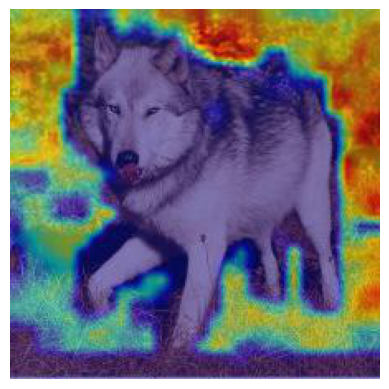

In [4]:
if IMG:
    try:
        out = PROJECT_DIR / "reproductions" / "huskywolf" / "cam.jpg"
        grad_cam_explain(IMG, weights_path=WEIGHTS, out_path=out)
        print("Saved Grad‑CAM to:", out)
        plt.imshow(Image.open(out)); plt.axis("off"); plt.show()
    except ImportError as e:
        print("Grad‑CAM not installed. Install with: pip install grad-cam imageio")